Script do develop evaluation procedure.

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"]="python"
from gliner import GLiNER
from gliner.training import Trainer, TrainingArguments as GlinerArgs
from gliner.data_processing.collator import DataCollator

from datasets import load_dataset

c:\Users\Desktop\miniforge3\envs\clirener_finetune\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dataset_processing import CLIRENER_LABELS_V1, transform_to_ner_format

In [3]:
dataset = load_dataset("P0L3/CliReNER_v_1_1_28_SILVER")


In [4]:
labels = dataset["train"].features["ner_tags"].feature.names


In [5]:
TRUE = dataset["test"]["ner_tags"]

In [6]:
model_path_or_id = "C:/Users/ANDRIJA_RAD/CLIRENER/CliReNER/EXPERIMENTS/models/GLINER/gliner_medium_v2_5_CliReNER_v_1_1_28_SILVER/checkpoint-final"
model = GLiNER.from_pretrained(model_path_or_id)

config.json not found in C:\Users\ANDRIJA_RAD\CLIRENER\CliReNER\EXPERIMENTS\models\GLINER\gliner_medium_v2_5_CliReNER_v_1_1_28_SILVER\checkpoint-final


In [7]:

model_predictions = []
for row in dataset["test"]:
    text = row["text"]
    labels = list(CLIRENER_LABELS_V1)

    entities = model.predict_entities(text, labels, threshold=0.1)
    model_predictions.append(
        {
    "text": text,
    "entities": entities
    }
    )

model_predictions_transformed = transform_to_ner_format(model_predictions, labels)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [8]:
model_predictions_ids = []
for row in model_predictions_transformed[0]:
    model_predictions_ids.append(row["ner_tags"])

In [9]:
def ids_to_labels(pred_id_seqs, label_list):
    """
    Convert sequences of prediction IDs into label sequences.

    Args:
        pred_id_seqs (list[list[int]]): e.g. model predictions [[2, 5, 0], ...]
        label_list (list[str]): label names from dataset, e.g. dataset["train"].features["ner_tags"].feature.names

    Returns:
        list[list[str]]: converted label sequences
    """
    return [[label_list[i] for i in seq] for seq in pred_id_seqs]


In [11]:
from nervaluate import Evaluator

labels = dataset["train"].features["ner_tags"].feature.names
true = ids_to_labels(TRUE, labels)
  
pred = ids_to_labels(model_predictions_ids, labels)
   
evaluator = Evaluator(true, pred, tags=list(CLIRENER_LABELS_V1), loader="list")

In [13]:
results, results_by_tag, result_indices, result_indices_by_tag = evaluator.evaluate()

import pandas as pd

df = pd.DataFrame(results)
print(df)

print("\n##results##:\n")
print("Strict: ", results["strict"])
print("Exact:  ", results["exact"])
print("\##results_by_tag##:\n")
print(results_by_tag)
print("\##result_indices##:\n")
print(result_indices)
print("\##result_indices_by_tag##:\n")
print(result_indices_by_tag)

              ent_type      partial       strict        exact
correct     620.000000   725.000000   580.000000   725.000000
incorrect   179.000000     0.000000   219.000000    74.000000
partial       0.000000    74.000000     0.000000     0.000000
missed        1.000000     1.000000     1.000000     1.000000
spurious    246.000000   246.000000   246.000000   246.000000
possible    800.000000   800.000000   800.000000   800.000000
actual     1045.000000  1045.000000  1045.000000  1045.000000
precision     0.593301     0.729187     0.555024     0.693780
recall        0.775000     0.952500     0.725000     0.906250
f1            0.672087     0.826016     0.628726     0.785908

##results##:

Strict:  {'correct': 580, 'incorrect': 219, 'partial': 0, 'missed': 1, 'spurious': 246, 'possible': 800, 'actual': 1045, 'precision': 0.5550239234449761, 'recall': 0.725, 'f1': 0.6287262872628726}
Exact:   {'correct': 725, 'incorrect': 74, 'partial': 0, 'missed': 1, 'spurious': 246, 'possible': 800, 'a

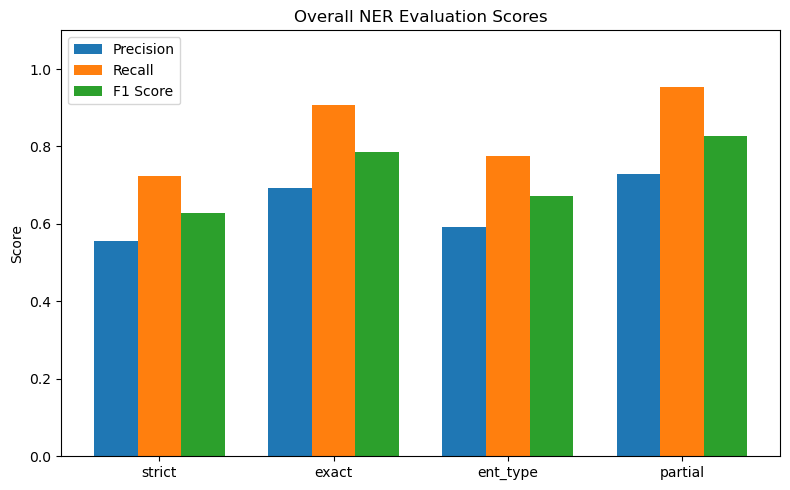

In [14]:
import matplotlib.pyplot as plt

def plot_overall_metrics(results):
    metrics = ['strict', 'exact', 'ent_type', 'partial']
    precision = [results[m]['precision'] for m in metrics]
    recall = [results[m]['recall'] for m in metrics]
    f1 = [results[m]['f1'] for m in metrics]

    x = range(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar([i - width for i in x], precision, width, label='Precision')
    ax.bar(x, recall, width, label='Recall')
    ax.bar([i + width for i in x], f1, width, label='F1 Score')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score")
    ax.set_title("Overall NER Evaluation Scores")
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_overall_metrics(results)